# Logistic Regression — Customer Churn Prediction

Modelo de regresión logística con parámetros estándar usando **todas las variables** del dataset.
Incluye encoding de variables categóricas, evaluación con cross-validation (ROC-AUC), entrenamiento final y envío de predicciones a Kaggle.

**Dataset:** Playground Series S6E3 — Telco Customer Churn  
**Modelo:** `sklearn.linear_model.LogisticRegression` (parámetros por defecto + `max_iter=1000`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Librerias cargadas")

Librerias cargadas


## 1. Carga y Preprocesamiento

In [2]:
train_raw = pd.read_csv("../../data/train.csv")
test_raw  = pd.read_csv("../../data/test.csv")

print(f"Train: {train_raw.shape[0]:,} filas x {train_raw.shape[1]} columnas")
print(f"Test:  {test_raw.shape[0]:,} filas x {test_raw.shape[1]} columnas")
print(f"\nColumnas: {list(train_raw.columns)}")

Train: 594,194 filas x 21 columnas
Test:  254,655 filas x 20 columnas

Columnas: ['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
def preprocess(df, is_train=True):
    df = df.copy()

    # Fix TotalCharges (puede tener espacios en blanco para tenure=0)
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

    # Columnas a descartar
    drop_cols = [c for c in ["id", "customerID", "CustomerId", "Surname"] if c in df.columns]
    if is_train:
        drop_cols += ["Churn"]
    df = df.drop(columns=drop_cols)

    # Encoding binario Yes/No
    binary_yn = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
    for col in binary_yn:
        if col in df.columns:
            df[col] = df[col].map({"Yes": 1, "No": 0})

    # Encoding gender
    if "gender" in df.columns:
        df["gender"] = df["gender"].map({"Male": 0, "Female": 1})

    # One-hot encoding de variables categoricas multi-nivel
    ohe_cols = [c for c in [
        "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
        "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
        "Contract", "PaymentMethod"
    ] if c in df.columns]

    df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

    return df


# Separar target antes de procesar
y = (train_raw["Churn"] == "Yes").astype(int).values
ids_test = test_raw["id"].values

# Preprocesar train y test en conjunto para alinear columnas one-hot
n_train = len(train_raw)
combined = pd.concat([train_raw.drop(columns=["Churn"]), test_raw], ignore_index=True)
combined["TotalCharges"] = pd.to_numeric(combined["TotalCharges"], errors="coerce").fillna(0)

drop_cols_all = [c for c in ["id", "customerID", "CustomerId", "Surname"] if c in combined.columns]
combined = combined.drop(columns=drop_cols_all)

binary_yn = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_yn:
    if col in combined.columns:
        combined[col] = combined[col].map({"Yes": 1, "No": 0})

if "gender" in combined.columns:
    combined["gender"] = combined["gender"].map({"Male": 0, "Female": 1})

ohe_cols = [c for c in [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
] if c in combined.columns]
combined = pd.get_dummies(combined, columns=ohe_cols, drop_first=True)

X_train = combined.iloc[:n_train].values.astype(float)
X_test  = combined.iloc[n_train:].values.astype(float)
feature_names = list(combined.columns)

# Estandarizar (recomendado para regresion logistica)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"{'='*80}")
print("PREPROCESAMIENTO COMPLETADO")
print(f"{'='*80}")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y:       {y.shape}  (churn rate: {y.mean():.2%})")
print(f"\nFeatures ({len(feature_names)}):")
for i, f in enumerate(feature_names, 1):
    print(f"  {i:2d}. {f}")
print(f"{'='*80}")

PREPROCESAMIENTO COMPLETADO
X_train: (594194, 30)
X_test:  (254655, 30)
y:       (594194,)  (churn rate: 22.52%)

Features (30):
   1. gender
   2. SeniorCitizen
   3. Partner
   4. Dependents
   5. tenure
   6. PhoneService
   7. PaperlessBilling
   8. MonthlyCharges
   9. TotalCharges
  10. MultipleLines_No phone service
  11. MultipleLines_Yes
  12. InternetService_Fiber optic
  13. InternetService_No
  14. OnlineSecurity_No internet service
  15. OnlineSecurity_Yes
  16. OnlineBackup_No internet service
  17. OnlineBackup_Yes
  18. DeviceProtection_No internet service
  19. DeviceProtection_Yes
  20. TechSupport_No internet service
  21. TechSupport_Yes
  22. StreamingTV_No internet service
  23. StreamingTV_Yes
  24. StreamingMovies_No internet service
  25. StreamingMovies_Yes
  26. Contract_One year
  27. Contract_Two year
  28. PaymentMethod_Credit card (automatic)
  29. PaymentMethod_Electronic check
  30. PaymentMethod_Mailed check


## 2. Resumen del Dataset Preprocesado

In [4]:
df_preview = pd.DataFrame(X_train, columns=feature_names)
print(f"Shape: {df_preview.shape}")
print(f"Balance del target: No churn={( y==0).sum():,}  ({(y==0).mean():.2%})  |  Churn={(y==1).sum():,}  ({(y==1).mean():.2%})")
df_preview.head(3)

Shape: (594194, 30)
Balance del target: No churn=460,377  (77.48%)  |  Churn=133,817  (22.52%)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-1.005539,-0.358885,0.958914,1.517947,-0.302342,0.255084,0.790791,-0.185604,-0.357076,-0.255084,...,1.613520,-0.557078,-0.824028,-0.557078,-0.827296,2.117755,-0.677522,-0.538845,-0.754010,1.949691
1,-1.005539,-0.358885,0.958914,1.517947,0.854793,0.255084,-1.264557,0.116964,0.545399,-0.255084,...,1.613520,-0.557078,1.213551,-0.557078,-0.827296,-0.472198,1.475966,1.855820,-0.754010,-0.512902
2,-1.005539,-0.358885,0.958914,-0.658785,0.854793,0.255084,0.790791,1.111575,1.421875,-0.255084,...,-0.619763,-0.557078,1.213551,-0.557078,1.208757,-0.472198,-0.677522,-0.538845,1.326243,-0.512902


## 3. Cross-Validation (5-Fold Estratificado)

In [5]:
model = LogisticRegression(max_iter=1000, random_state=42)
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_aucs = []
fold_fprs = []
fold_tprs = []
best_fold_idx = 0

print(f"{'='*80}")
print("CROSS-VALIDATION — Logistic Regression (5-fold)")
print(f"{'='*80}")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y), 1):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_val)[:, 1]

    fold_auc = roc_auc_score(y_val, y_prob)
    fold_aucs.append(fold_auc)

    fpr, tpr, _ = roc_curve(y_val, y_prob)
    fold_fprs.append(fpr)
    fold_tprs.append(tpr)

    if fold_auc == max(fold_aucs):
        best_fold_idx = fold - 1

    print(f"  Fold {fold}: AUC = {fold_auc:.4f}")

print(f"{'='*80}")
print(f"  Media:  {np.mean(fold_aucs):.4f}")
print(f"  Std:    {np.std(fold_aucs):.4f}")
print(f"  Mejor fold: {best_fold_idx + 1} (AUC = {max(fold_aucs):.4f})")
print(f"{'='*80}")

CROSS-VALIDATION — Logistic Regression (5-fold)
  Fold 1: AUC = 0.9075
  Fold 2: AUC = 0.9089
  Fold 3: AUC = 0.9081
  Fold 4: AUC = 0.9091
  Fold 5: AUC = 0.9061
  Media:  0.9079
  Std:    0.0011
  Mejor fold: 4 (AUC = 0.9091)


## 4. Curva ROC

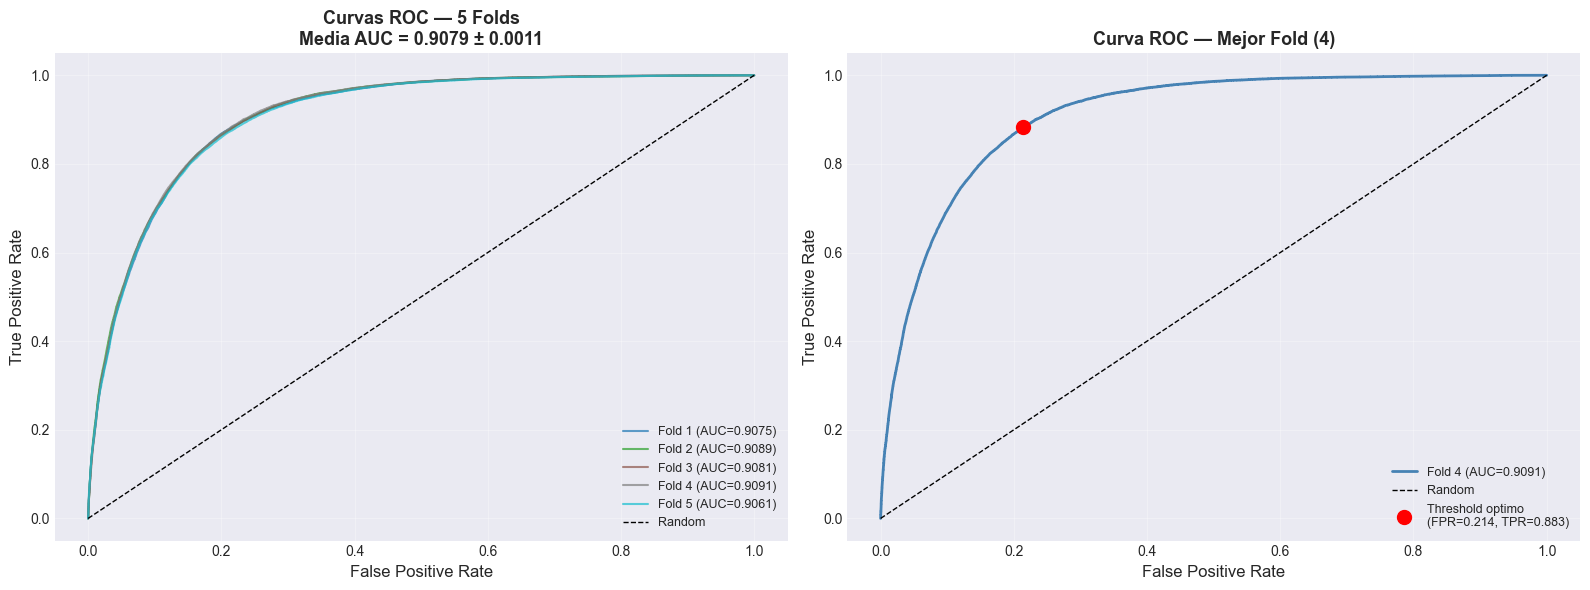

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Izquierda: todos los folds
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, len(fold_aucs)))
for i, (fpr, tpr, auc_val) in enumerate(zip(fold_fprs, fold_tprs, fold_aucs), 1):
    ax.plot(fpr, tpr, color=colors[i-1], alpha=0.7, lw=1.5, label=f"Fold {i} (AUC={auc_val:.4f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"Curvas ROC — 5 Folds\nMedia AUC = {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Derecha: mejor fold con threshold optimo
ax2 = axes[1]
best_fpr = fold_fprs[best_fold_idx]
best_tpr = fold_tprs[best_fold_idx]
best_auc = fold_aucs[best_fold_idx]

ax2.plot(best_fpr, best_tpr, color="steelblue", lw=2, label=f"Fold {best_fold_idx+1} (AUC={best_auc:.4f})")
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label="Random")

# Threshold optimo (punto mas cercano a (0,1))
opt_idx = np.argmax(best_tpr - best_fpr)
ax2.scatter(best_fpr[opt_idx], best_tpr[opt_idx], color="red", zorder=5, s=100,
            label=f"Threshold optimo\n(FPR={best_fpr[opt_idx]:.3f}, TPR={best_tpr[opt_idx]:.3f})")
ax2.set_xlabel("False Positive Rate", fontsize=12)
ax2.set_ylabel("True Positive Rate", fontsize=12)
ax2.set_title(f"Curva ROC — Mejor Fold ({best_fold_idx+1})", fontsize=13, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Entrenamiento Final

In [7]:
final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_train, y)

print(f"{'='*80}")
print("MODELO ENTRENADO EN TODO EL CONJUNTO DE ENTRENAMIENTO")
print(f"{'='*80}")
print(f"Solver:   {final_model.solver}")
print(f"C:        {final_model.C}")
print(f"max_iter: {final_model.max_iter}")
print(f"n_iter:   {final_model.n_iter_[0]} (iteraciones reales hasta convergencia)")
print(f"n_feats:  {final_model.n_features_in_}")
print(f"{'='*80}")

MODELO ENTRENADO EN TODO EL CONJUNTO DE ENTRENAMIENTO
Solver:   lbfgs
C:        1.0
max_iter: 1000
n_iter:   29 (iteraciones reales hasta convergencia)
n_feats:  30


COEFICIENTES — ordenados por |coef|
tenure                                       : -1.8078  -████████████████████████████████████
TotalCharges                                 : +0.7934  +███████████████
Contract_Two year                            : -0.6593  -█████████████
InternetService_Fiber optic                  : +0.4448  +████████
PaymentMethod_Electronic check               : +0.3285  +██████
Contract_One year                            : -0.2924  -█████
PaperlessBilling                             : +0.1996  +███
OnlineSecurity_Yes                           : -0.1719  -███
MultipleLines_Yes                            : +0.1613  +███
StreamingTV_Yes                              : +0.1566  +███
Dependents                                   : -0.1494  -██
StreamingMovies_Yes                          : +0.1435  +██
SeniorCitizen                                : +0.1390  +██
TechSupport_Yes                              : -0.1077  -██
MonthlyCharges                               : +0

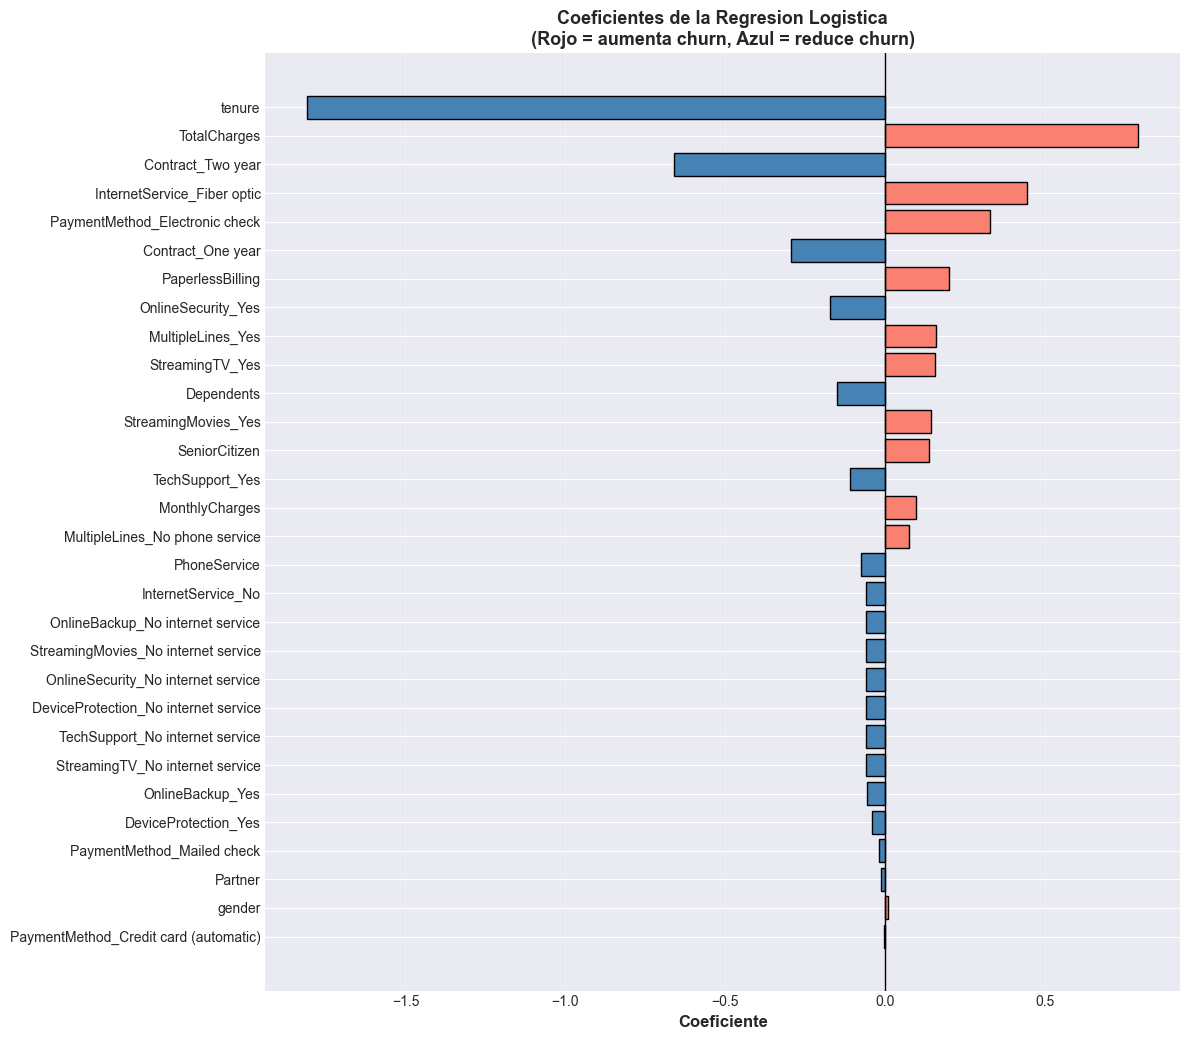

In [8]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": final_model.coef_[0]
}).reindex(pd.Series(final_model.coef_[0]).abs().sort_values(ascending=False).index)

coef_df = coef_df.sort_values("coef", key=abs, ascending=False).reset_index(drop=True)

print(f"{'='*80}")
print("COEFICIENTES — ordenados por |coef|")
print(f"{'='*80}")
for _, row in coef_df.iterrows():
    bar = '\u2588' * int(abs(row['coef']) * 20)
    sign = '+' if row['coef'] >= 0 else '-'
    print(f"{row['feature']:45s}: {row['coef']:+7.4f}  {sign}{bar}")
print(f"{'='*80}")

# Visualizacion
plt.figure(figsize=(12, max(6, len(coef_df) * 0.35)))
colors_bar = ["salmon" if c > 0 else "steelblue" for c in coef_df["coef"]]
plt.barh(coef_df["feature"], coef_df["coef"], color=colors_bar, edgecolor="black")
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Coeficiente", fontsize=12, fontweight="bold")
plt.title("Coeficientes de la Regresion Logistica\n(Rojo = aumenta churn, Azul = reduce churn)",
          fontsize=13, fontweight="bold")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 6. Predicciones sobre Test

PREDICCIONES SOBRE TEST
Registros:   254,655
Probabilidad media: 0.2205
Min:         0.0001
Max:         0.9807


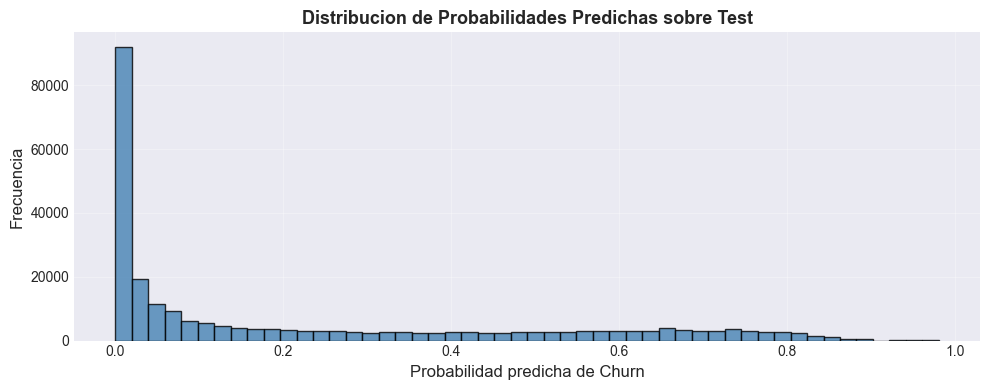

In [9]:
test_probs = final_model.predict_proba(X_test)[:, 1]

print(f"{'='*80}")
print("PREDICCIONES SOBRE TEST")
print(f"{'='*80}")
print(f"Registros:   {len(test_probs):,}")
print(f"Probabilidad media: {test_probs.mean():.4f}")
print(f"Min:         {test_probs.min():.4f}")
print(f"Max:         {test_probs.max():.4f}")
print(f"{'='*80}")

# Distribucion de probabilidades predichas
plt.figure(figsize=(10, 4))
plt.hist(test_probs, bins=50, color="steelblue", edgecolor="black", alpha=0.8)
plt.xlabel("Probabilidad predicha de Churn", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.title("Distribucion de Probabilidades Predichas sobre Test", fontsize=13, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
import os

submission = pd.DataFrame({
    "id":    ids_test,
    "Churn": test_probs.round(4)
})

submission_path = "../../data/1_LR_submission.csv"
submission.to_csv(submission_path, index=False)

print(f"{'='*80}")
print("SUBMISSION GENERADA")
print(f"{'='*80}")
print(f"Archivo: {os.path.abspath(submission_path)}")
print(f"Filas:   {len(submission):,}")
print(f"Columnas: {list(submission.columns)}")
print(f"\nPrimeras filas:")
print(submission.head(5).to_string(index=False))
print(f"{'='*80}")

SUBMISSION GENERADA
Archivo: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\DGKaggle\Playground Series\Season 6\Episode 3 - Predict Customer Churn\data\1_LR_submission.csv
Filas:   254,655
Columnas: ['id', 'Churn']

Primeras filas:
    id  Churn
594194 0.0533
594195 0.0002
594196 0.1197
594197 0.0035
594198 0.5020


## 7. Envío a Kaggle

In [11]:
!kaggle competitions submit -c playground-series-s6e3 -f ../../data/1_LR_submission.csv -m "LR sklearn - todas las variables"

Successfully submitted to Predict Customer Churn



  0%|          | 0.00/3.62M [00:00<?, ?B/s]
  0%|          | 16.0k/3.62M [00:00<00:51, 74.0kB/s]
  5%|▌         | 192k/3.62M [00:00<00:05, 649kB/s]  
 14%|█▍        | 528k/3.62M [00:00<00:04, 789kB/s]
 17%|█▋        | 624k/3.62M [00:00<00:03, 790kB/s]
 36%|███▋      | 1.31M/3.62M [00:01<00:01, 2.01MB/s]
 43%|████▎     | 1.56M/3.62M [00:01<00:01, 2.03MB/s]
 50%|████▉     | 1.80M/3.62M [00:01<00:00, 2.10MB/s]
 58%|█████▊    | 2.09M/3.62M [00:01<00:00, 2.34MB/s]
100%|██████████| 3.62M/3.62M [00:02<00:00, 1.89MB/s]
